<a href="https://colab.research.google.com/github/Taniice/Algoritmos-Geneticos-Actividad-06/blob/main/Actividad_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

a.	Usan los algoritmos genéticos para hallar las mejores características (optimización), también conocido como “feature selection” de un modelo de aprendizaje de máquina.

In [ ]:
# ============================================================
# ALGORITMO GENÉTICO PARA FEATURE SELECTION
# DATASET: BREAST CANCER WISCONSIN
# ============================================================

# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Para obtener siempre los mismos resultados
random.seed(42)
np.random.seed(42)


# ============================================================
# 2. CARGAR DATASET
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target

nombres_caracteristicas = data.feature_names


print("=" * 60)
print("DATASET BREAST CANCER WISCONSIN")
print("=" * 60)

print("\nCantidad de registros:", X.shape[0])
print("Cantidad de características:", X.shape[1])
print("Cantidad de clases:", len(np.unique(y)))


print("\nCaracterísticas:")

for i, nombre in enumerate(nombres_caracteristicas):
    print(f"{i:02d} -> {nombre}")


DATASET BREAST CANCER WISCONSIN

Cantidad de registros: 569
Cantidad de características: 30
Cantidad de clases: 2

Características:
00 -> mean radius
01 -> mean texture
02 -> mean perimeter
03 -> mean area
04 -> mean smoothness
05 -> mean compactness
06 -> mean concavity
07 -> mean concave points
08 -> mean symmetry
09 -> mean fractal dimension
10 -> radius error
11 -> texture error
12 -> perimeter error
13 -> area error
14 -> smoothness error
15 -> compactness error
16 -> concavity error
17 -> concave points error
18 -> symmetry error
19 -> fractal dimension error
20 -> worst radius
21 -> worst texture
22 -> worst perimeter
23 -> worst area
24 -> worst smoothness
25 -> worst compactness
26 -> worst concavity
27 -> worst concave points
28 -> worst symmetry
29 -> worst fractal dimension


In [ ]:
# ============================================================
# 3. DIVIDIR DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nDatos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)



Datos de entrenamiento: (455, 30)
Datos de prueba: (114, 30)


In [ ]:
# ============================================================
# 4. CONFIGURACIÓN DEL CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 5. FUNCIÓN FITNESS
# ============================================================

def calcular_fitness(individuo):

    # Obtener las posiciones de las características seleccionadas
    indices = [
        i for i, gen in enumerate(individuo)
        if gen == 1
    ]

    # Si no seleccionó ninguna característica
    if len(indices) == 0:
        return 0

    # Seleccionar características
    X_seleccionado = X_train[:, indices]

    # Crear modelo
    modelo = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    # Cross Validation
    resultados = cross_val_score(
        modelo,
        X_seleccionado,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    # Accuracy promedio
    accuracy = resultados.mean()

    # --------------------------------------------------------
    # PENALIZACIÓN POR USAR MUCHAS CARACTERÍSTICAS
    # --------------------------------------------------------

    cantidad_caracteristicas = len(indices)
    total_caracteristicas = len(individuo)

    porcentaje_caracteristicas = (
        cantidad_caracteristicas /
        total_caracteristicas
    )

    # Penalización pequeña
    penalizacion = 0.01 * porcentaje_caracteristicas

    # Fitness final
    fitness = accuracy - penalizacion

    return fitness


# ============================================================
# 6. CREAR INDIVIDUO
# ============================================================

def crear_individuo():

    individuo = [
        random.randint(0, 1)
        for _ in range(X.shape[1])
    ]

    # Asegurarnos de que tenga al menos una característica
    if sum(individuo) == 0:
        posicion = random.randint(0, X.shape[1] - 1)
        individuo[posicion] = 1

    return individuo


# ============================================================
# 7. CREAR POBLACIÓN INICIAL
# ============================================================

tamano_poblacion = 20

poblacion = [
    crear_individuo()
    for _ in range(tamano_poblacion)
]


print("\n" + "=" * 60)
print("POBLACIÓN INICIAL")
print("=" * 60)

for i, individuo in enumerate(poblacion):

    print(
        f"Individuo {i+1:02d}: "
        f"{individuo} | "
        f"Características: {sum(individuo)}"
    )


# ============================================================
# 8. FUNCIÓN DE SELECCIÓN
# ============================================================

def seleccionar_padres(poblacion, fitness):

    # Combinar individuo + fitness
    individuos_fitness = list(
        zip(poblacion, fitness)
    )

    # Ordenar de mayor a menor fitness
    individuos_fitness.sort(
        key=lambda x: x[1],
        reverse=True
    )

    # Seleccionar los mejores
    cantidad_padres = 6

    padres = [
        individuo.copy()
        for individuo, valor in
        individuos_fitness[:cantidad_padres]
    ]

    return padres


# ============================================================
# 9. FUNCIÓN CROSSOVER
# ============================================================

def crossover(padre1, padre2):

    # Elegir punto de corte
    punto = random.randint(
        1,
        len(padre1) - 1
    )

    # Crear hijo
    hijo = (
        padre1[:punto] +
        padre2[punto:]
    )

    return hijo


# ============================================================
# 10. FUNCIÓN MUTACIÓN
# ============================================================

def mutar(individuo, probabilidad):

    individuo = individuo.copy()

    for i in range(len(individuo)):

        # Generar número aleatorio
        if random.random() < probabilidad:

            # Cambiar 0 por 1
            # o 1 por 0
            individuo[i] = 1 - individuo[i]

    # Evitar que quede sin características
    if sum(individuo) == 0:

        posicion = random.randint(
            0,
            len(individuo) - 1
        )

        individuo[posicion] = 1

    return individuo



POBLACIÓN INICIAL
Individuo 01: [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0] | Características: 9
Individuo 02: [1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0] | Características: 16
Individuo 03: [0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0] | Características: 16
Individuo 04: [0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1] | Características: 14
Individuo 05: [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0] | Características: 13
Individuo 06: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1] | Características: 11
Individuo 07: [1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1] | Características: 12
Individuo 08: [0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 

In [ ]:
# ============================================================
# 11. PARÁMETROS DEL ALGORITMO GENÉTICO
# ============================================================

generaciones = 20

probabilidad_mutacion = 0.05


# Variables para guardar el mejor resultado
mejor_individuo_global = None
mejor_fitness_global = -999

historial_fitness = []
historial_caracteristicas = []


# ============================================================
# 12. ALGORITMO GENÉTICO
# ============================================================

print("\n" + "=" * 60)
print("EVOLUCIÓN DEL ALGORITMO GENÉTICO")
print("=" * 60)


for generacion in range(generaciones):

    # --------------------------------------------------------
    # EVALUAR CADA INDIVIDUO
    # --------------------------------------------------------

    fitness_poblacion = []

    for individuo in poblacion:

        fitness = calcular_fitness(individuo)

        fitness_poblacion.append(fitness)


    # --------------------------------------------------------
    # ENCONTRAR MEJOR INDIVIDUO
    # --------------------------------------------------------

    mejor_posicion = np.argmax(
        fitness_poblacion
    )

    mejor_individuo = poblacion[
        mejor_posicion
    ]

    mejor_fitness = fitness_poblacion[
        mejor_posicion
    ]

    cantidad = sum(mejor_individuo)


    # --------------------------------------------------------
    # GUARDAR MEJOR RESULTADO GLOBAL
    # --------------------------------------------------------

    if mejor_fitness > mejor_fitness_global:

        mejor_fitness_global = mejor_fitness

        mejor_individuo_global = (
            mejor_individuo.copy()
        )


    historial_fitness.append(
        mejor_fitness_global
    )

    historial_caracteristicas.append(
        sum(mejor_individuo_global)
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO
    # --------------------------------------------------------

    print(
        f"Generación {generacion + 1:02d} | "
        f"Fitness: {mejor_fitness:.4f} | "
        f"Características: {cantidad}"
    )


    # --------------------------------------------------------
    # SELECCIÓN
    # --------------------------------------------------------

    padres = seleccionar_padres(
        poblacion,
        fitness_poblacion
    )


    # --------------------------------------------------------
    # NUEVA POBLACIÓN
    # --------------------------------------------------------

    nueva_poblacion = []


    # Elitismo:
    # conservar el mejor individuo
    nueva_poblacion.append(
        mejor_individuo.copy()
    )


    # Crear nuevos individuos
    while len(nueva_poblacion) < tamano_poblacion:

        # Elegir dos padres
        padre1 = random.choice(padres)
        padre2 = random.choice(padres)

        # Crossover
        hijo = crossover(
            padre1,
            padre2
        )

        # Mutación
        hijo = mutar(
            hijo,
            probabilidad_mutacion
        )

        nueva_poblacion.append(hijo)


    # Reemplazar población
    poblacion = nueva_poblacion



EVOLUCIÓN DEL ALGORITMO GENÉTICO
Generación 01 | Fitness: 0.9646 | Características: 14
Generación 02 | Fitness: 0.9664 | Características: 15
Generación 03 | Fitness: 0.9715 | Características: 13
Generación 04 | Fitness: 0.9715 | Características: 13
Generación 05 | Fitness: 0.9715 | Características: 13
Generación 06 | Fitness: 0.9715 | Características: 13
Generación 07 | Fitness: 0.9730 | Características: 15
Generación 08 | Fitness: 0.9730 | Características: 15
Generación 09 | Fitness: 0.9730 | Características: 15
Generación 10 | Fitness: 0.9730 | Características: 15
Generación 11 | Fitness: 0.9730 | Características: 15
Generación 12 | Fitness: 0.9730 | Características: 15
Generación 13 | Fitness: 0.9730 | Características: 15
Generación 14 | Fitness: 0.9730 | Características: 15
Generación 15 | Fitness: 0.9730 | Características: 15
Generación 16 | Fitness: 0.9730 | Características: 15
Generación 17 | Fitness: 0.9730 | Características: 15
Generación 18 | Fitness: 0.9730 | Característica

In [ ]:
# ============================================================
# 13. RESULTADO FINAL
# ============================================================

print("\n" + "=" * 60)
print("🏆 MEJOR SOLUCIÓN ENCONTRADA")
print("=" * 60)


print("\nCromosoma:")

print(mejor_individuo_global)


print(
    "\nCantidad de características seleccionadas:",
    sum(mejor_individuo_global),
    "de",
    len(mejor_individuo_global)
)


print("\nCaracterísticas seleccionadas:")


caracteristicas_seleccionadas = []

for i, gen in enumerate(mejor_individuo_global):

    if gen == 1:

        caracteristicas_seleccionadas.append(
            nombres_caracteristicas[i]
        )

        print(
            "✓",
            nombres_caracteristicas[i]
        )


print(
    "\nFitness final:",
    round(mejor_fitness_global, 4)
)



🏆 MEJOR SOLUCIÓN ENCONTRADA

Cromosoma:
[0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1]

Cantidad de características seleccionadas: 15 de 30

Características seleccionadas:
✓ mean texture
✓ mean concave points
✓ mean fractal dimension
✓ radius error
✓ texture error
✓ perimeter error
✓ smoothness error
✓ compactness error
✓ symmetry error
✓ fractal dimension error
✓ worst texture
✓ worst area
✓ worst smoothness
✓ worst concavity
✓ worst fractal dimension

Fitness final: 0.973


In [ ]:
# ============================================================
# 14. EVALUAR MODELO CON TODAS LAS CARACTERÍSTICAS
# ============================================================

modelo_completo = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


modelo_completo.fit(
    X_train,
    y_train
)


predicciones_completo = (
    modelo_completo.predict(X_test)
)


accuracy_completo = accuracy_score(
    y_test,
    predicciones_completo
)


# ============================================================
# 15. EVALUAR MODELO CON CARACTERÍSTICAS SELECCIONADAS
# ============================================================

indices_seleccionados = [
    i
    for i, gen in enumerate(
        mejor_individuo_global
    )
    if gen == 1
]


X_train_reducido = (
    X_train[:, indices_seleccionados]
)

X_test_reducido = (
    X_test[:, indices_seleccionados]
)


modelo_reducido = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


modelo_reducido.fit(
    X_train_reducido,
    y_train
)


predicciones_reducido = (
    modelo_reducido.predict(
        X_test_reducido
    )
)


accuracy_reducido = accuracy_score(
    y_test,
    predicciones_reducido
)




COMPARACIÓN FINAL

Modelo con TODAS las características:
Características: 30
Accuracy: 0.9561

Modelo con FEATURE SELECTION:
Características: 15
Accuracy: 0.9737

Reducción de características: 50.0 %


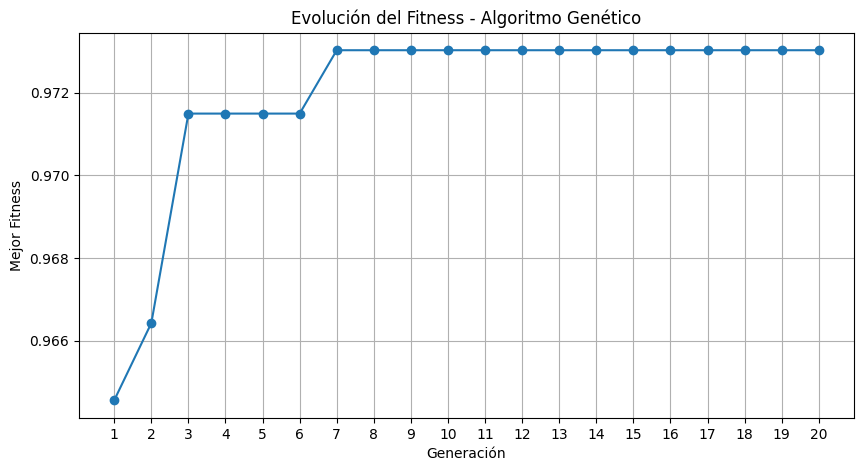

In [ ]:
# ============================================================
# 16. COMPARACIÓN FINAL
# ============================================================

print("\n" + "=" * 60)
print("COMPARACIÓN FINAL")
print("=" * 60)


print(
    "\nModelo con TODAS las características:"
)

print(
    "Características:",
    X.shape[1]
)

print(
    "Accuracy:",
    round(accuracy_completo, 4)
)


print(
    "\nModelo con FEATURE SELECTION:"
)

print(
    "Características:",
    len(indices_seleccionados)
)

print(
    "Accuracy:",
    round(accuracy_reducido, 4)
)


# ============================================================
# 17. PORCENTAJE DE REDUCCIÓN
# ============================================================

reduccion = (
    1 -
    len(indices_seleccionados) /
    X.shape[1]
) * 100


print(
    "\nReducción de características:",
    round(reduccion, 2),
    "%"
)


# ============================================================
# 18. GRÁFICA DEL FITNESS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, generaciones + 1),
    historial_fitness,
    marker="o"
)

plt.xlabel("Generación")
plt.ylabel("Mejor Fitness")
plt.title(
    "Evolución del Fitness - Algoritmo Genético"
)

plt.xticks(
    range(1, generaciones + 1)
)

plt.grid(True)

plt.show()


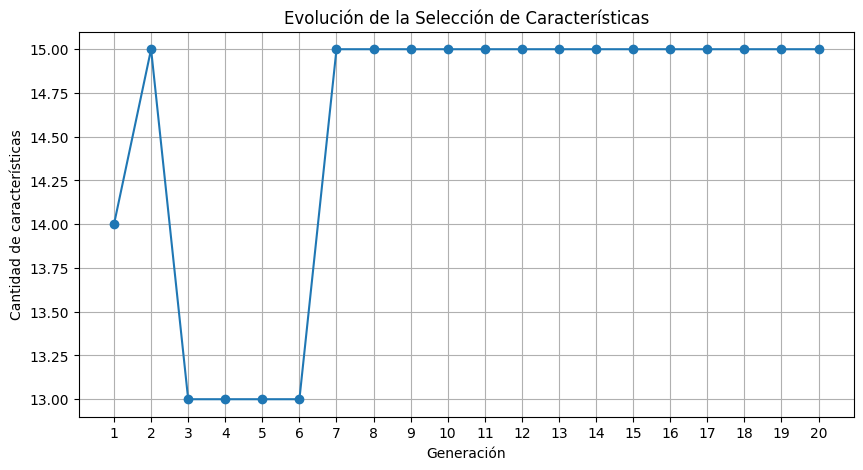

In [ ]:
# ============================================================
# 19. GRÁFICA DE CANTIDAD DE CARACTERÍSTICAS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, generaciones + 1),
    historial_caracteristicas,
    marker="o"
)

plt.xlabel("Generación")

plt.ylabel(
    "Cantidad de características"
)

plt.title(
    "Evolución de la Selección de Características"
)

plt.xticks(
    range(1, generaciones + 1)
)

plt.grid(True)

plt.show()

Se implementó un algoritmo genético para realizar selección de características. Cada individuo representa una posible combinación de características mediante un cromosoma binario, donde 1 indica que una característica es seleccionada y 0 que es descartada. La función fitness evalúa el desempeño de un Random Forest mediante validación cruzada y aplica una penalización por utilizar demasiadas características. Mediante selección, crossover y mutación, el algoritmo evoluciona la población hasta encontrar un subconjunto de características que mantenga un buen desempeño predictivo reduciendo la dimensionalidad.

b.	Usar los algoritmos genéticos para hallar los mejores hiper parámetros de un modelo de aprendizaje de máquina, también conocido como “Hyperparameter optimization”

In [ ]:
# ============================================================
# ALGORITMO GENÉTICO PARA HYPERPARAMETER OPTIMIZATION
# DATASET: BREAST CANCER WISCONSIN
# MODELO: RANDOM FOREST
# ============================================================


# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score


# ============================================================
# 2. FIJAR SEMILLAS
# ============================================================

random.seed(42)
np.random.seed(42)


# ============================================================
# 3. CARGAR DATASET
# ============================================================

data = load_breast_cancer()

X = data.data
y = data.target


print("=" * 60)
print("DATASET BREAST CANCER WISCONSIN")
print("=" * 60)

print("\nCantidad de registros:", X.shape[0])
print("Cantidad de características:", X.shape[1])
print("Cantidad de clases:", len(np.unique(y)))


# ============================================================
# 4. DIVIDIR DATASET
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nDatos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)


# ============================================================
# 5. CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


DATASET BREAST CANCER WISCONSIN

Cantidad de registros: 569
Cantidad de características: 30
Cantidad de clases: 2

Datos de entrenamiento: (455, 30)
Datos de prueba: (114, 30)


In [ ]:
# ============================================================
# 6. RANGOS DE HIPERPARÁMETROS
# ============================================================

# Cada gen del cromosoma representa un hiperparámetro.

rangos = {

    "n_estimators": [50, 100, 150, 200],

    "max_depth": [3, 5, 8, 10, 15, 20, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]

}


# ============================================================
# 7. CREAR INDIVIDUO
# ============================================================

def crear_individuo():

    individuo = {

        "n_estimators": random.choice(
            rangos["n_estimators"]
        ),

        "max_depth": random.choice(
            rangos["max_depth"]
        ),

        "min_samples_split": random.choice(
            rangos["min_samples_split"]
        ),

        "min_samples_leaf": random.choice(
            rangos["min_samples_leaf"]
        )
    }

    return individuo


# ============================================================
# 8. FUNCIÓN FITNESS
# ============================================================

def calcular_fitness(individuo):

    modelo = RandomForestClassifier(

        n_estimators=individuo["n_estimators"],

        max_depth=individuo["max_depth"],

        min_samples_split=individuo["min_samples_split"],

        min_samples_leaf=individuo["min_samples_leaf"],

        random_state=42,

        n_jobs=-1
    )


    # Evaluar mediante Cross Validation

    resultados = cross_val_score(

        modelo,

        X_train,

        y_train,

        cv=cv,

        scoring="accuracy",

        n_jobs=-1
    )


    # Accuracy promedio

    fitness = resultados.mean()


    return fitness



In [ ]:
# ============================================================
# 9. CREAR POBLACIÓN INICIAL
# ============================================================

tamano_poblacion = 10

poblacion = [

    crear_individuo()

    for _ in range(tamano_poblacion)
]


print("\n" + "=" * 60)
print("POBLACIÓN INICIAL")
print("=" * 60)


for i, individuo in enumerate(poblacion):

    print(
        f"\nIndividuo {i + 1}:"
    )

    print(
        "  n_estimators:",
        individuo["n_estimators"]
    )

    print(
        "  max_depth:",
        individuo["max_depth"]
    )

    print(
        "  min_samples_split:",
        individuo["min_samples_split"]
    )

    print(
        "  min_samples_leaf:",
        individuo["min_samples_leaf"]
    )


# ============================================================
# 10. SELECCIÓN
# ============================================================

def seleccionar_padres(
    poblacion,
    fitness_poblacion
):

    individuos_fitness = list(
        zip(
            poblacion,
            fitness_poblacion
        )
    )


    # Ordenar de mejor a peor

    individuos_fitness.sort(
        key=lambda x: x[1],
        reverse=True
    )


    # Seleccionar los mejores

    cantidad_padres = 4


    padres = [

        individuo.copy()

        for individuo, fitness
        in individuos_fitness[
            :cantidad_padres
        ]

    ]


    return padres


# ============================================================
# 11. CROSSOVER
# ============================================================

def crossover(
    padre1,
    padre2
):

    hijo = {}


    # Para cada hiperparámetro,
    # elegir el valor de uno de los padres.

    for parametro in rangos.keys():

        if random.random() < 0.5:

            hijo[parametro] = padre1[parametro]

        else:

            hijo[parametro] = padre2[parametro]


    return hijo


# ============================================================
# 12. MUTACIÓN
# ============================================================

def mutar(
    individuo,
    probabilidad
):

    individuo = individuo.copy()


    # Recorrer los hiperparámetros

    for parametro in rangos.keys():

        if random.random() < probabilidad:

            individuo[parametro] = random.choice(
                rangos[parametro]
            )


    return individuo


# ============================================================
# 13. PARÁMETROS DEL ALGORITMO GENÉTICO
# ============================================================

generaciones = 15

probabilidad_mutacion = 0.20


# Variables para guardar resultados

mejor_individuo_global = None

mejor_fitness_global = -1

historial_fitness = []


# ============================================================
# 14. ALGORITMO GENÉTICO
# ============================================================

print("\n" + "=" * 60)
print("EVOLUCIÓN DEL ALGORITMO GENÉTICO")
print("=" * 60)


for generacion in range(generaciones):


    # --------------------------------------------------------
    # EVALUAR POBLACIÓN
    # --------------------------------------------------------

    fitness_poblacion = []


    for individuo in poblacion:

        fitness = calcular_fitness(
            individuo
        )

        fitness_poblacion.append(
            fitness
        )


    # --------------------------------------------------------
    # ENCONTRAR MEJOR INDIVIDUO
    # --------------------------------------------------------

    mejor_posicion = np.argmax(
        fitness_poblacion
    )


    mejor_individuo = poblacion[
        mejor_posicion
    ]


    mejor_fitness = fitness_poblacion[
        mejor_posicion
    ]


    # --------------------------------------------------------
    # ACTUALIZAR MEJOR GLOBAL
    # --------------------------------------------------------

    if mejor_fitness > mejor_fitness_global:

        mejor_fitness_global = (
            mejor_fitness
        )

        mejor_individuo_global = (
            mejor_individuo.copy()
        )


    historial_fitness.append(
        mejor_fitness_global
    )


    # --------------------------------------------------------
    # MOSTRAR RESULTADO
    # --------------------------------------------------------

    print(
        f"\nGeneración {generacion + 1:02d}"
    )

    print(
        "Mejor Fitness:",
        round(
            mejor_fitness,
            4
        )
    )

    print(
        "n_estimators:",
        mejor_individuo[
            "n_estimators"
        ]
    )

    print(
        "max_depth:",
        mejor_individuo[
            "max_depth"
        ]
    )

    print(
        "min_samples_split:",
        mejor_individuo[
            "min_samples_split"
        ]
    )

    print(
        "min_samples_leaf:",
        mejor_individuo[
            "min_samples_leaf"
        ]
    )


    # --------------------------------------------------------
    # SELECCIÓN
    # --------------------------------------------------------

    padres = seleccionar_padres(
        poblacion,
        fitness_poblacion
    )


    # --------------------------------------------------------
    # CREAR NUEVA POBLACIÓN
    # --------------------------------------------------------

    nueva_poblacion = []


    # ELITISMO
    # Mantener al mejor individuo

    nueva_poblacion.append(
        mejor_individuo_global.copy()
    )


    # Crear nuevos individuos

    while len(nueva_poblacion) < tamano_poblacion:

        padre1 = random.choice(
            padres
        )

        padre2 = random.choice(
            padres
        )


        # CROSSOVER

        hijo = crossover(
            padre1,
            padre2
        )


        # MUTACIÓN

        hijo = mutar(
            hijo,
            probabilidad_mutacion
        )


        nueva_poblacion.append(
            hijo
        )


    # Reemplazar población

    poblacion = nueva_poblacion




POBLACIÓN INICIAL

Individuo 1:
  n_estimators: 50
  max_depth: 3
  min_samples_split: 10
  min_samples_leaf: 2

Individuo 2:
  n_estimators: 100
  max_depth: 5
  min_samples_split: 2
  min_samples_leaf: 4

Individuo 3:
  n_estimators: 50
  max_depth: 20
  min_samples_split: 10
  min_samples_leaf: 4

Individuo 4:
  n_estimators: 50
  max_depth: 15
  min_samples_split: 5
  min_samples_leaf: 1

Individuo 5:
  n_estimators: 50
  max_depth: 3
  min_samples_split: 2
  min_samples_leaf: 1

Individuo 6:
  n_estimators: 50
  max_depth: 15
  min_samples_split: 2
  min_samples_leaf: 4

Individuo 7:
  n_estimators: 200
  max_depth: 5
  min_samples_split: 5
  min_samples_leaf: 4

Individuo 8:
  n_estimators: 150
  max_depth: None
  min_samples_split: 2
  min_samples_leaf: 1

Individuo 9:
  n_estimators: 200
  max_depth: 8
  min_samples_split: 5
  min_samples_leaf: 1

Individuo 10:
  n_estimators: 100
  max_depth: None
  min_samples_split: 5
  min_samples_leaf: 1

EVOLUCIÓN DEL ALGORITMO GENÉTICO


In [ ]:
# ============================================================
# 15. MEJOR SOLUCIÓN ENCONTRADA
# ============================================================

print("\n" + "=" * 60)
print(" MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("=" * 60)


print(
    "\nFitness:",
    round(
        mejor_fitness_global,
        4
    )
)


for parametro, valor in (
    mejor_individuo_global.items()
):

    print(
        f"{parametro}: {valor}"
    )


# ============================================================
# 16. ENTRENAR MODELO CON LOS MEJORES HIPERPARÁMETROS
# ============================================================

modelo_genetico = RandomForestClassifier(

    n_estimators=
    mejor_individuo_global[
        "n_estimators"
    ],

    max_depth=
    mejor_individuo_global[
        "max_depth"
    ],

    min_samples_split=
    mejor_individuo_global[
        "min_samples_split"
    ],

    min_samples_leaf=
    mejor_individuo_global[
        "min_samples_leaf"
    ],

    random_state=42,

    n_jobs=-1
)


modelo_genetico.fit(
    X_train,
    y_train
)


# ============================================================
# 17. EVALUAR EN TEST
# ============================================================

predicciones_genetico = (
    modelo_genetico.predict(
        X_test
    )
)


accuracy_genetico = accuracy_score(
    y_test,
    predicciones_genetico
)


print(
    "\nAccuracy final con "
    "hiperparámetros optimizados:",
    round(
        accuracy_genetico,
        4
    )
)


# ============================================================
# 18. MODELO BASE
# ============================================================

modelo_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


modelo_base.fit(
    X_train,
    y_train
)


predicciones_base = (
    modelo_base.predict(
        X_test
    )
)


accuracy_base = accuracy_score(
    y_test,
    predicciones_base
)



🏆 MEJORES HIPERPARÁMETROS ENCONTRADOS

Fitness: 0.967
n_estimators: 150
max_depth: 8
min_samples_split: 2
min_samples_leaf: 1

Accuracy final con hiperparámetros optimizados: 0.9474



COMPARACIÓN FINAL

Modelo base:
Accuracy: 0.9561

Modelo optimizado con Algoritmo Genético:
Accuracy: 0.9474

Mejora: -0.0088


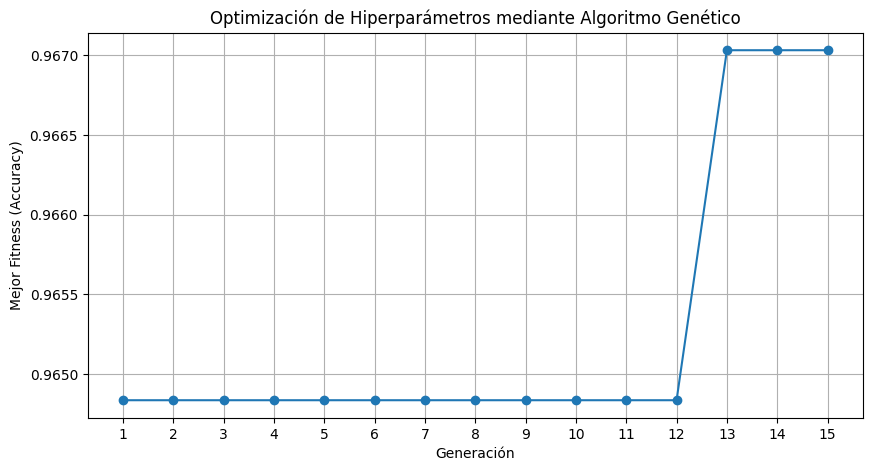

In [ ]:
# ============================================================
# 19. COMPARACIÓN
# ============================================================

print("\n" + "=" * 60)
print("COMPARACIÓN FINAL")
print("=" * 60)


print(
    "\nModelo base:"
)

print(
    "Accuracy:",
    round(
        accuracy_base,
        4
    )
)


print(
    "\nModelo optimizado con "
    "Algoritmo Genético:"
)

print(
    "Accuracy:",
    round(
        accuracy_genetico,
        4
    )
)


mejora = (
    accuracy_genetico -
    accuracy_base
)


print(
    "\nMejora:",
    round(
        mejora,
        4
    )
)


# ============================================================
# 20. GRÁFICA DE EVOLUCIÓN
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    range(
        1,
        generaciones + 1
    ),

    historial_fitness,

    marker="o"
)


plt.xlabel(
    "Generación"
)

plt.ylabel(
    "Mejor Fitness (Accuracy)"
)

plt.title(
    "Optimización de Hiperparámetros "
    "mediante Algoritmo Genético"
)


plt.xticks(
    range(
        1,
        generaciones + 1
    )
)


plt.grid(
    True
)

plt.show()

c.	Usan los algoritmos genéticos para hallar la mejor arquitectura de una red neuronal o “Neuroevolution”.

In [1]:
# ============================================================
# 1: IMPORTAR LIBRERÍAS
# ============================================================

# Librería para trabajar con los datos
import pandas as pd
import numpy as np

# Librería para realizar gráficos
import matplotlib.pyplot as plt

# Para dividir los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Para estandarizar los datos
from sklearn.preprocessing import StandardScaler

# Métricas para evaluar el modelo
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Red neuronal
from sklearn.neural_network import MLPClassifier

# Para evitar mensajes innecesarios
import warnings
warnings.filterwarnings("ignore")

# Fijamos una semilla para poder reproducir los resultados
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ============================================================
# BLOQUE 2: CARGAR DATASET WINE QUALITY
# ============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# El dataset utiliza ";" como separador
df = pd.read_csv(url, sep=";")

print("Dataset cargado correctamente.")
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

# Mostrar las primeras filas
df.head()

Dataset cargado correctamente.
Cantidad de filas: 1599
Cantidad de columnas: 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# ============================================================
# 3: EXPLORAR EL DATASET
# ============================================================

print("Información del dataset:")
print()

df.info()

Información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# Mostrar cuántos vinos existen para cada nivel de calidad
print("Distribución de la calidad:")
print(df["quality"].value_counts().sort_index())

Distribución de la calidad:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [5]:
# ============================================================
# 4: CREAR VARIABLE OBJETIVO
# ============================================================

# Creamos una nueva columna llamada "quality_class"

df["quality_class"] = np.where(
    df["quality"] >= 6,
    1,
    0
)

print("Distribución de las clases:")
print(df["quality_class"].value_counts())

print()
print("0 = Calidad baja")
print("1 = Calidad alta")

Distribución de las clases:
quality_class
1    855
0    744
Name: count, dtype: int64

0 = Calidad baja
1 = Calidad alta


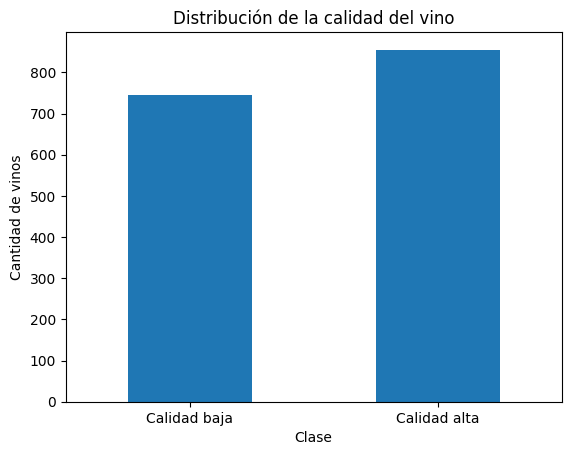

In [6]:
# ============================================================
# GRÁFICO DE LAS CLASES
# ============================================================

df["quality_class"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribución de la calidad del vino")
plt.xlabel("Clase")
plt.ylabel("Cantidad de vinos")
plt.xticks(
    [0, 1],
    ["Calidad baja", "Calidad alta"],
    rotation=0
)

plt.show()

In [7]:
# ============================================================
# 5: SEPARAR CARACTERÍSTICAS Y VARIABLE OBJETIVO
# ============================================================

X = df.drop(
    columns=["quality", "quality_class"]
)

y = df["quality_class"]

print("Características utilizadas:")
print(X.columns.tolist())

print()
print("Cantidad de características:", X.shape[1])
print("Cantidad de ejemplos:", X.shape[0])

Características utilizadas:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Cantidad de características: 11
Cantidad de ejemplos: 1599


In [8]:
# ============================================================
# 6: TRAIN Y TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (1279, 11)
Datos de prueba: (320, 11)


In [9]:
# ============================================================
# 7: ESTANDARIZACIÓN
# ============================================================

scaler = StandardScaler()

# Ajustamos el scaler solamente con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos la misma transformación al conjunto de prueba
X_test_scaled = scaler.transform(X_test)

print("Datos estandarizados correctamente.")

Datos estandarizados correctamente.


In [16]:
# ============================================================
# BLOQUE 8: CREAR ARQUITECTURAS ALEATORIAS
# ============================================================

def crear_individuo():
    """
    Crea una arquitectura de red neuronal aleatoria.

    Cada individuo puede tener entre 1 y 3 capas ocultas.
    Cada capa puede tener entre 8 y 64 neuronas.
    """

    # Elegimos aleatoriamente cuántas capas tendrá la red
    numero_capas = np.random.randint(1, 4)

    # Creamos las neuronas de cada capa
    arquitectura = []

    for i in range(numero_capas):

        # Elegimos un número de neuronas
        # int() convierte np.int64 a un entero normal de Python
        neuronas = int(np.random.choice(
            [8, 16, 32, 64]
        ))

        arquitectura.append(neuronas)

    return arquitectura

In [17]:
# Generamos 10 arquitecturas
for i in range(10):
    print(crear_individuo())

[16]
[64]
[16]
[8, 64, 16]
[64]
[8]
[32]
[8]
[32]
[64]


In [18]:
# ============================================================
# BLOQUE 9: FUNCIÓN FITNESS
# ============================================================

def evaluar_individuo(arquitectura):

    # Creamos una red neuronal utilizando
    # la arquitectura recibida.
    modelo = MLPClassifier(
        hidden_layer_sizes=tuple(arquitectura),

        # Función de activación
        activation="relu",

        # Optimizador
        solver="adam",

        # Número de iteraciones para entrenar
        max_iter=300,

        # Semilla para reproducibilidad
        random_state=42,

        # Evita mostrar mensajes durante el entrenamiento
        verbose=False
    )

    # Entrenamos la red neuronal
    modelo.fit(
        X_train_scaled,
        y_train
    )

    # Realizamos predicciones
    predicciones = modelo.predict(
        X_test_scaled
    )

    # Calculamos accuracy
    accuracy = accuracy_score(
        y_test,
        predicciones
    )

    return accuracy

In [19]:
# ============================================================
# PRUEBA DE UNA ARQUITECTURA
# ============================================================

arquitectura_prueba = [32, 16]

fitness = evaluar_individuo(
    arquitectura_prueba
)

print("Arquitectura:", arquitectura_prueba)
print("Fitness:", round(fitness, 4))

Arquitectura: [32, 16]
Fitness: 0.7531


In [20]:
# ============================================================
# 10: POBLACIÓN INICIAL
# ============================================================

TAMANO_POBLACION = 10

poblacion = []

for i in range(TAMANO_POBLACION):

    individuo = crear_individuo()

    poblacion.append(individuo)

print("POBLACIÓN INICIAL")
print("=" * 40)

for i, individuo in enumerate(poblacion):

    print(
        "Individuo",
        i + 1,
        "→",
        individuo
    )

POBLACIÓN INICIAL
Individuo 1 → [64]
Individuo 2 → [32, 32, 8]
Individuo 3 → [32, 8, 32]
Individuo 4 → [16]
Individuo 5 → [16, 8, 64]
Individuo 6 → [8, 64, 64]
Individuo 7 → [8, 64]
Individuo 8 → [32, 16, 64]
Individuo 9 → [32]
Individuo 10 → [32, 32]


In [21]:
# ============================================================
# 11: EVALUAR POBLACIÓN
# ============================================================

def evaluar_poblacion(poblacion):

    resultados = []

    for individuo in poblacion:

        fitness = evaluar_individuo(
            individuo
        )

        resultados.append(
            (individuo, fitness)
        )

    return resultados

In [22]:
# Evaluamos la población inicial

resultados = evaluar_poblacion(
    poblacion
)

# Ordenamos de mejor a peor
resultados = sorted(
    resultados,
    key=lambda x: x[1],
    reverse=True
)

print("RESULTADOS DE LA POBLACIÓN")
print("=" * 50)

for individuo, fitness in resultados:

    print(
        f"Arquitectura: {individuo} "
        f"| Fitness: {fitness:.4f}"
    )

RESULTADOS DE LA POBLACIÓN
Arquitectura: [32, 32] | Fitness: 0.7875
Arquitectura: [32, 32, 8] | Fitness: 0.7844
Arquitectura: [16, 8, 64] | Fitness: 0.7844
Arquitectura: [32, 8, 32] | Fitness: 0.7719
Arquitectura: [32] | Fitness: 0.7688
Arquitectura: [64] | Fitness: 0.7656
Arquitectura: [8, 64] | Fitness: 0.7656
Arquitectura: [32, 16, 64] | Fitness: 0.7625
Arquitectura: [16] | Fitness: 0.7531
Arquitectura: [8, 64, 64] | Fitness: 0.7438


In [23]:
# ============================================================
# 12: SELECCIÓN
# ============================================================

def seleccion(resultados, numero_padres=4):

    # Ordenamos de mayor a menor fitness
    resultados = sorted(
        resultados,
        key=lambda x: x[1],
        reverse=True
    )

    # Nos quedamos con los mejores individuos
    padres = [
        individuo
        for individuo, fitness
        in resultados[:numero_padres]
    ]

    return padres

In [24]:
padres = seleccion(
    resultados,
    numero_padres=4
)

print("PADRES SELECCIONADOS")
print("=" * 40)

for padre in padres:
    print(padre)

PADRES SELECCIONADOS
[32, 32]
[32, 32, 8]
[16, 8, 64]
[32, 8, 32]


In [25]:
# ============================================================
# 13: CRUCE
# ============================================================

def cruce(padre1, padre2):

    # Elegimos aleatoriamente hasta dónde
    # tomar información de cada padre.

    punto1 = np.random.randint(
        0,
        len(padre1) + 1
    )

    punto2 = np.random.randint(
        0,
        len(padre2) + 1
    )

    # Combinamos las dos arquitecturas
    hijo = (
        padre1[:punto1] +
        padre2[punto2:]
    )

    # Si por alguna combinación queda vacío,
    # creamos una capa mínima.
    if len(hijo) == 0:
        hijo = [8]

    # Limitamos el máximo a 3 capas
    hijo = hijo[:3]

    return hijo

In [26]:
padre1 = [32, 16]
padre2 = [64, 32, 16]

hijo = cruce(
    padre1,
    padre2
)

print("Padre 1:", padre1)
print("Padre 2:", padre2)
print("Hijo:", hijo)

Padre 1: [32, 16]
Padre 2: [64, 32, 16]
Hijo: [16]


In [27]:
# ============================================================
# 14: MUTACIÓN
# ============================================================

def mutacion(individuo, probabilidad=0.20):

    # Creamos una copia para no modificar
    # directamente el individuo original.
    individuo = individuo.copy()

    # Decidimos si ocurre una mutación
    if np.random.rand() < probabilidad:

        # Elegimos una capa al azar
        posicion = np.random.randint(
            0,
            len(individuo)
        )

        # Cambiamos el número de neuronas
        individuo[posicion] = np.random.choice(
            [8, 16, 32, 64]
        )

    return individuo

In [29]:
# ============================================================
# 15: NUEVA GENERACIÓN
# ============================================================

def crear_nueva_generacion(
    resultados,
    tamano_poblacion
):

    # Seleccionamos los mejores
    padres = seleccion(
        resultados,
        numero_padres=4
    )

    nueva_poblacion = []

    # Conservamos directamente al mejor individuo
    mejor_individuo = resultados[0][0]

    nueva_poblacion.append(
        mejor_individuo
    )

    # Creamos nuevos individuos
    while len(nueva_poblacion) < tamano_poblacion:

        # Elegimos dos padres
        padre1 = padres[
            np.random.randint(len(padres))
        ]

        padre2 = padres[
            np.random.randint(len(padres))
        ]

        # Cruzamos los padres
        hijo = cruce(
            padre1,
            padre2
        )

        # Aplicamos mutación
        hijo = mutacion(
            hijo
        )

        nueva_poblacion.append(
            hijo
        )

    return nueva_poblacion

In [30]:
# ============================================================
# 16: ALGORITMO GENÉTICO
# ============================================================

NUMERO_GENERACIONES = 10

# Guardamos el mejor fitness de cada generación
historial_fitness = []

# Guardamos la mejor arquitectura de cada generación
historial_arquitecturas = []

# Comenzamos con la población inicial
poblacion_actual = poblacion


for generacion in range(NUMERO_GENERACIONES):

    print()
    print("=" * 60)
    print("GENERACIÓN", generacion + 1)
    print("=" * 60)

    # Evaluamos todos los individuos
    resultados = evaluar_poblacion(
        poblacion_actual
    )

    # Ordenamos de mejor a peor
    resultados = sorted(
        resultados,
        key=lambda x: x[1],
        reverse=True
    )

    # Obtenemos el mejor individuo
    mejor_arquitectura = resultados[0][0]

    mejor_fitness = resultados[0][1]

    # Guardamos los resultados
    historial_fitness.append(
        mejor_fitness
    )

    historial_arquitecturas.append(
        mejor_arquitectura
    )

    print(
        "Mejor arquitectura:",
        mejor_arquitectura
    )

    print(
        "Mejor fitness:",
        round(mejor_fitness, 4)
    )

    # Crear nueva generación
    poblacion_actual = crear_nueva_generacion(
        resultados,
        TAMANO_POBLACION
    )


GENERACIÓN 1
Mejor arquitectura: [32, 32]
Mejor fitness: 0.7875

GENERACIÓN 2
Mejor arquitectura: [32, 32, 16]
Mejor fitness: 0.8031

GENERACIÓN 3
Mejor arquitectura: [32, 32, 16]
Mejor fitness: 0.8031

GENERACIÓN 4
Mejor arquitectura: [32, 32, 16]
Mejor fitness: 0.8031

GENERACIÓN 5
Mejor arquitectura: [32, 32, 16]
Mejor fitness: 0.8031

GENERACIÓN 6
Mejor arquitectura: [32, 32, 16]
Mejor fitness: 0.8031

GENERACIÓN 7
Mejor arquitectura: [32, 32, 16]
Mejor fitness: 0.8031

GENERACIÓN 8
Mejor arquitectura: [32, 32, 16]
Mejor fitness: 0.8031

GENERACIÓN 9
Mejor arquitectura: [32, 32, 16]
Mejor fitness: 0.8031

GENERACIÓN 10
Mejor arquitectura: [32, 32, 16]
Mejor fitness: 0.8031


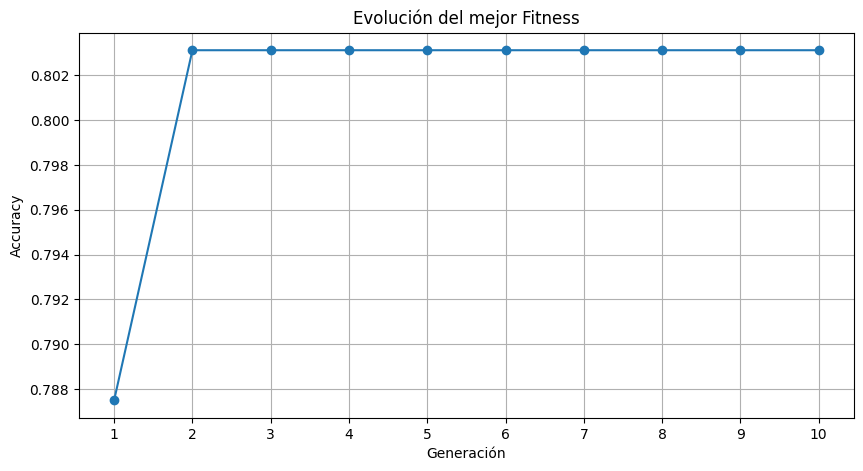

In [31]:
# ============================================================
# BLOQUE 17: GRÁFICO DE EVOLUCIÓN
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, NUMERO_GENERACIONES + 1),
    historial_fitness,
    marker="o"
)

plt.title(
    "Evolución del mejor Fitness"
)

plt.xlabel(
    "Generación"
)

plt.ylabel(
    "Accuracy"
)

plt.xticks(
    range(1, NUMERO_GENERACIONES + 1)
)

plt.grid()

plt.show()

In [32]:
# ============================================================
# BLOQUE 18: MEJOR ARQUITECTURA
# ============================================================

# Encontramos la posición donde obtuvimos
# el mayor fitness

indice_mejor = np.argmax(
    historial_fitness
)

mejor_arquitectura = (
    historial_arquitecturas[
        indice_mejor
    ]
)

mejor_fitness = (
    historial_fitness[
        indice_mejor
    ]
)

print("=" * 60)
print("MEJOR ARQUITECTURA ENCONTRADA")
print("=" * 60)

print(
    "Arquitectura:",
    mejor_arquitectura
)

print(
    "Número de capas ocultas:",
    len(mejor_arquitectura)
)

print(
    "Neuronas por capa:",
    mejor_arquitectura
)

print(
    "Fitness:",
    round(mejor_fitness, 4)
)

MEJOR ARQUITECTURA ENCONTRADA
Arquitectura: [32, 32, 16]
Número de capas ocultas: 3
Neuronas por capa: [32, 32, 16]
Fitness: 0.8031


In [33]:
# ============================================================
# 19: MODELO FINAL
# ============================================================

modelo_final = MLPClassifier(
    hidden_layer_sizes=tuple(
        mejor_arquitectura
    ),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# Entrenamos el modelo final
modelo_final.fit(
    X_train_scaled,
    y_train
)

# Realizamos predicciones
y_pred = modelo_final.predict(
    X_test_scaled
)

print("Modelo final entrenado correctamente.")

Modelo final entrenado correctamente.


In [34]:
# ============================================================
# 20: EVALUACIÓN FINAL
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("=" * 60)
print("RESULTADOS DEL MODELO FINAL")
print("=" * 60)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1-Score : {f1:.4f}"
)

RESULTADOS DEL MODELO FINAL
Accuracy : 0.8031
Precision: 0.8103
Recall   : 0.8246
F1-Score : 0.8174


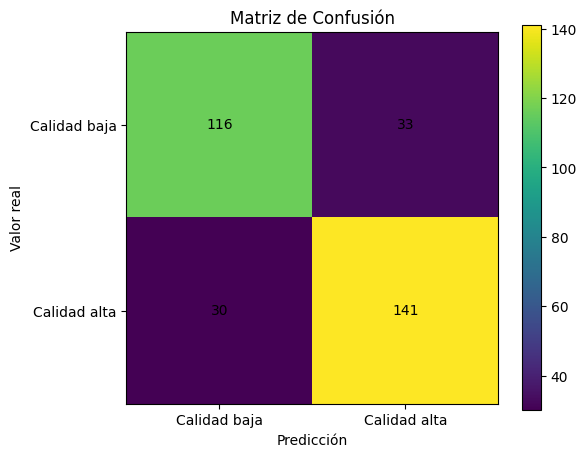

In [35]:
# ============================================================
# 21: MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Matriz de Confusión"
)

plt.xlabel(
    "Predicción"
)

plt.ylabel(
    "Valor real"
)

plt.xticks(
    [0, 1],
    ["Calidad baja", "Calidad alta"]
)

plt.yticks(
    [0, 1],
    ["Calidad baja", "Calidad alta"]
)

# Mostrar los valores dentro de la matriz
for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [36]:
# ============================================================
# 22: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Calidad baja",
            "Calidad alta"
        ]
    )
)

              precision    recall  f1-score   support

Calidad baja       0.79      0.78      0.79       149
Calidad alta       0.81      0.82      0.82       171

    accuracy                           0.80       320
   macro avg       0.80      0.80      0.80       320
weighted avg       0.80      0.80      0.80       320



In [37]:
# ============================================================
# 23: EVOLUCIÓN DE LAS ARQUITECTURAS
# ============================================================

print("=" * 70)
print("EVOLUCIÓN DE LA NEUROEVOLUTION")
print("=" * 70)

for i in range(NUMERO_GENERACIONES):

    print(
        f"Generación {i + 1:2d} "
        f"| Arquitectura: {historial_arquitecturas[i]} "
        f"| Fitness: {historial_fitness[i]:.4f}"
    )

EVOLUCIÓN DE LA NEUROEVOLUTION
Generación  1 | Arquitectura: [32, 32] | Fitness: 0.7875
Generación  2 | Arquitectura: [32, 32, 16] | Fitness: 0.8031
Generación  3 | Arquitectura: [32, 32, 16] | Fitness: 0.8031
Generación  4 | Arquitectura: [32, 32, 16] | Fitness: 0.8031
Generación  5 | Arquitectura: [32, 32, 16] | Fitness: 0.8031
Generación  6 | Arquitectura: [32, 32, 16] | Fitness: 0.8031
Generación  7 | Arquitectura: [32, 32, 16] | Fitness: 0.8031
Generación  8 | Arquitectura: [32, 32, 16] | Fitness: 0.8031
Generación  9 | Arquitectura: [32, 32, 16] | Fitness: 0.8031
Generación 10 | Arquitectura: [32, 32, 16] | Fitness: 0.8031
